Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Framework de Deep Learning et utilitaires de vision par ordinateur
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Métriques d'évaluation et protocoles de segmentation de données
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# Gestion de la progression des processus itératifs
from tqdm import tqdm

def set_seed(seed=42):
    """
    Assure la reproductibilité des résultats en fixant les graines aléatoires 
    pour les différentes bibliothèques utilisées.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Désactivation des algorithmes non-déterministes de CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initialisation de la reproductibilité et sélection du périphérique de calcul
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Système configuré sur : {device}")

Système configuré sur : cpu


In [2]:
def crop_to_square(img, threshold=10):
    """Recadre au plus près et ajoute du padding noir pour rester carré."""
    img_gray = img.convert('L')
    img_np = np.array(img_gray)
    coords = np.argwhere(img_np > threshold)
    if coords.size == 0: return img.resize((224, 224))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    brain_crop = img.crop((x_min, y_min, x_max, y_max))
    width, height = brain_crop.size
    max_side = max(width, height)
    square_img = Image.new("RGB", (max_side, max_side), (0, 0, 0))
    square_img.paste(brain_crop, ((max_side - width) // 2, (max_side - height) // 2))
    return square_img.resize((224, 224))

Import des datas

In [3]:
# Chargement du jeu de données issu de la phase de clustering (Notebook 3)
df_final = pd.read_pickle("../features/final_weak_labels.pkl")

# Normalisation des étiquettes : conversion des catégories textuelles en indices numériques
# 'normal' -> 0, 'cancer' -> 1
label_map = {'normal': 0, 'cancer': 1}
df_final['true_label_idx'] = df_final['label'].map(label_map)

# Vérification de la distribution des classes connues
print("Répartition des données étiquetées par les experts :")
print(df_final[df_final['label'] != 'Unknown']['label'].value_counts())
print(f"\nVolume total du dataset : {len(df_final)} échantillons.")

Répartition des données étiquetées par les experts :
label
cancer    50
normal    49
Name: count, dtype: int64

Volume total du dataset : 1501 échantillons.


Constitution du jeu de test de référence (Hold-out Set)

In [4]:
# Extraction des échantillons possédant une étiquette experte (Strong Labels)
df_strong = df_final[df_final['label'] != 'Unknown'].copy()
df_strong['target'] = df_strong['true_label_idx'].astype(int)

print(f"Volume de données expertes pour la validation croisée : {len(df_strong)} images.")

Volume de données expertes pour la validation croisée : 99 images.


In [5]:
train_strong_df, test_df = train_test_split(df_strong, test_size=0.20, stratify=df_strong['label'], random_state=42)

Préparation des sous-ensembles d'entraînement pour le protocole semi-supervisé

In [6]:
# Extraction des données "Unknown" pour l'entraînement sur étiquettes faibles (Weak Labels)
# Ces données utilisent la prédiction issue du clustering K-Means.
df_weak = df_final[df_final['label'] == 'Unknown'].copy()

# Définition de l'étiquette cible pour la phase de pré-entraînement
# On utilise ici la colonne 'weak_label' générée.
df_weak['target'] = df_weak['weak_label']

# Pour le jeu d'entraînement supervisé, la cible est l'étiquette experte
train_strong_df['target'] = train_strong_df['true_label_idx'].astype(int)

# Pour le jeu de test, la cible est également l'étiquette experte
test_df['target'] = test_df['true_label_idx'].astype(int)

print(f"Données disponibles pour l'apprentissage semi-supervisé :")
print(f"- Ensemble 'Weak' (Pseudo-labels) : {len(df_weak)} images")
print(f"- Ensemble 'Strong' (Labels experts) : {len(train_strong_df)} images")

Données disponibles pour l'apprentissage semi-supervisé :
- Ensemble 'Weak' (Pseudo-labels) : 1402 images
- Ensemble 'Strong' (Labels experts) : 79 images


Pipeline d'entraînement

In [7]:
#  inclut l'augmentation pour la robustesse du modèle
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pipeline de validation/test : aucune transformation aléatoire pour garantir la reproductibilité
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
class BrainMRIDataset(Dataset):
    """
    Dataset optimisé pour l'entraînement du CNN.
    Charge les images, applique le recadrage (Crop) et les transformations.
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Chargement et prétraitement géométrique (standardisation du cadrage)
        image = Image.open(row['path']).convert('RGB')
        
        # Note : On réutilise ici la fonction crop_to_square définie précédemment 
        # pour assurer la cohérence avec l'extraction des features.
        image = crop_to_square(image)
        
        if self.transform:
            image = self.transform(image)
            
        # La cible 'target' est l'index numérique (0 ou 1)
        target = torch.tensor(row['target'], dtype=torch.long)
        
        return image, target

In [9]:
# Configuration des hyperparamètres de chargement
BATCH_SIZE = 32

# Création des objets Dataset
weak_train_set = BrainMRIDataset(df_weak, transform=train_transform)
strong_train_set = BrainMRIDataset(train_strong_df, transform=train_transform)
test_set = BrainMRIDataset(test_df, transform=test_transform)

# Initialisation des DataLoaders pour la gestion des batchs
weak_loader = DataLoader(weak_train_set, batch_size=BATCH_SIZE, shuffle=True)
strong_loader = DataLoader(strong_train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders prêts :")
print(f"- Batchs 'Weak' : {len(weak_loader)}")
print(f"- Batchs 'Strong' : {len(strong_loader)}")
print(f"- Batchs 'Test' : {len(test_loader)}")

DataLoaders prêts :
- Batchs 'Weak' : 44
- Batchs 'Strong' : 3
- Batchs 'Test' : 1


Configuration de l'architecture ResNet18

In [10]:
def get_brain_model(num_classes=2):
    """
    Initialise un modèle ResNet18 pré-entraîné et adapte la couche de sortie 
    pour la classification binaire (Normal vs Cancer).
    """
    # Chargement du modèle avec les poids issus d'ImageNet (meilleure convergence)
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Extraction du nombre de caractéristiques en entrée de la dernière couche
    num_ftrs = model.fc.in_features
    
    # Remplacement de la couche Fully Connected (FC) par une couche adaptée à notre tâche
    # La sortie possède 2 neurones (un par classe)
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

# Initialisation du modèle et transfert sur le périphérique de calcul (GPU/CPU)
model = get_brain_model().to(device)

print(f"Modèle ResNet18 initialisé et configuré pour {device}.")

Modèle ResNet18 initialisé et configuré pour cpu.


In [11]:
# Fonction de coût : CrossEntropyLoss est le standard pour la classification multi-classe
# Elle gère automatiquement l'application de la fonction Softmax en sortie
criterion = nn.CrossEntropyLoss()

# Optimiseur : Adam est privilégié pour sa gestion adaptative du taux d'apprentissage (learning rate)
# Un learning rate faible (1e-4) assure une convergence stable lors du fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Fonction de perte et Optimiseur configurés.")

Fonction de perte et Optimiseur configurés.


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Exécute une itération complète sur l'ensemble du jeu de données d'entraînement.
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        # Réinitialisation des gradients
        optimizer.zero_grad()

        # Passage avant (Forward pass)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Rétropropagation et optimisation
        loss.backward()
        optimizer.step()

        # Statistiques
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

def evaluate_model(model, loader, criterion, device):
    """
    Évalue la performance du modèle sur un jeu de données de test ou de validation.
    Le calcul des gradients est désactivé pour optimiser les ressources.
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    return val_loss, val_acc, val_f1

In [13]:
def run_training_session(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=10):
    """
    Supervise le cycle d'apprentissage sur plusieurs époques et enregistre les métriques.
    """
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'test_loss': [], 'test_acc': [], 'test_f1': []
    }
    
    for epoch in range(num_epochs):
        # 1. Phase d'entraînement
        t_loss, t_acc, t_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # 2. Phase de validation (sur le jeu de test)
        v_loss, v_acc, v_f1 = evaluate_model(model, test_loader, criterion, device)
        
        # 3. Stockage des métriques
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['train_f1'].append(t_f1)
        history['test_loss'].append(v_loss)
        history['test_acc'].append(v_acc)
        history['test_f1'].append(v_f1)
        
        print(f"Époque {epoch+1:02d}/{num_epochs} | Train F1: {t_f1:.4f} - Test F1: {v_f1:.4f} | Test Loss: {v_loss:.4f}")
        
    return history

In [14]:
def evaluate_baseline_cv(df, num_folds=5, epochs=15):
    """
    Exécute une validation croisée stratifiée pour évaluer la performance de base (Baseline).
    Garantit que chaque image est utilisée pour l'entraînement et l'évaluation de manière équitable.
    """
    # Initialisation du scindeur stratifié
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_scores = []
    
    print(f"Démarrage de la validation croisée ({num_folds} plis)...")
    
    # Itération sur chaque pli (Fold)
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['target'])):
        print(f"\n--- Pli {fold + 1}/{num_folds} ---")
        
        # 1. Segmentation des données pour le pli courant
        train_fold_df = df.iloc[train_idx].copy()
        val_fold_df = df.iloc[val_idx].copy()
        
        # 2. Instanciation des DataLoaders spécifiques au pli
        train_set = BrainMRIDataset(train_fold_df, transform=train_transform)
        val_set = BrainMRIDataset(val_fold_df, transform=test_transform) # Application de test_transform (sans augmentation)
        
        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
        
        # 3. Initialisation d'un modèle vierge (Crucial pour éviter la fuite de poids)
        model_cv = get_brain_model().to(device)
        optimizer_cv = optim.Adam(model_cv.parameters(), lr=1e-4)
        
        # 4. Entraînement du modèle sur le pli courant
        history = run_training_session(
            model=model_cv,
            train_loader=train_loader,
            test_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_cv,
            device=device,
            num_epochs=epochs
        )
        
        # 5. Enregistrement de la performance finale (Dernière époque)
        final_val_f1 = history['test_f1'][-1]
        fold_scores.append(final_val_f1)
        print(f"Score F1 (Validation) pour le pli {fold + 1} : {final_val_f1:.4f}")
        
    # 6. Synthèse statistique globale
    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    
    print("\n" + "="*60)
    print(" BILAN DE LA VALIDATION CROISÉE (BASELINE SUPERVISÉE) ")
    print("="*60)
    print(f"F1-Score Moyen : {mean_f1:.4f} (+/- {std_f1:.4f})")
    print("="*60)
    
    return mean_f1, std_f1



In [15]:
print("="*60)
print(" ÉVALUATION DE LA ROBUSTESSE (VALIDATION CROISÉE) ")
print("="*60)

# On lance la CV uniquement sur les données d'entraînement pour ne pas tricher
# avec le jeu de test final.
mean_baseline_f1, std_baseline_f1 = evaluate_baseline_cv(train_strong_df, num_folds=5, epochs=15)

 ÉVALUATION DE LA ROBUSTESSE (VALIDATION CROISÉE) 
Démarrage de la validation croisée (5 plis)...

--- Pli 1/5 ---


Époque 01/15 | Train F1: 0.5741 - Test F1: 0.4589 | Test Loss: 0.6534


Époque 02/15 | Train F1: 0.9683 - Test F1: 0.8057 | Test Loss: 0.6129


Époque 03/15 | Train F1: 0.9524 - Test F1: 0.8057 | Test Loss: 0.6480


Époque 04/15 | Train F1: 0.9841 - Test F1: 0.7460 | Test Loss: 0.7134


...

Époque 11/15 | Train F1: 1.0000 - Test F1: 0.7982 | Test Loss: 0.5304


Époque 12/15 | Train F1: 1.0000 - Test F1: 0.7982 | Test Loss: 0.5392


Époque 13/15 | Train F1: 1.0000 - Test F1: 0.7982 | Test Loss: 0.5443


Époque 14/15 | Train F1: 1.0000 - Test F1: 0.7982 | Test Loss: 0.5514


Époque 15/15 | Train F1: 1.0000 - Test F1: 0.7982 | Test Loss: 0.5616
Score F1 (Validation) pour le pli 5 : 0.7982

 BILAN DE LA VALIDATION CROISÉE (BASELINE SUPERVISÉE) 
F1-Score Moyen : 0.9220 (+/- 0.0956)


In [16]:
# Initialisation d'une instance ResNet18 vierge (poids ImageNet de base)
model_supervised = get_brain_model().to(device)
optimizer_sup = optim.Adam(model_supervised.parameters(), lr=1e-4)

EPOCHS_SUPERVISED = 15

print("="*60)
print(" DÉBUT DE L'ENTRAÎNEMENT SUPERVISÉ (BASELINE : 80 IMAGES) ")
print("="*60)

history_supervised = run_training_session(
    model=model_supervised,
    train_loader=strong_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_sup,
    device=device,
    num_epochs=EPOCHS_SUPERVISED
)

 DÉBUT DE L'ENTRAÎNEMENT SUPERVISÉ (BASELINE : 80 IMAGES) 


Époque 01/15 | Train F1: 0.6006 - Test F1: 0.4357 | Test Loss: 0.7723


Époque 02/15 | Train F1: 0.9620 - Test F1: 0.8465 | Test Loss: 0.4905


Époque 03/15 | Train F1: 1.0000 - Test F1: 0.9499 | Test Loss: 0.3269


Époque 04/15 | Train F1: 0.9873 - Test F1: 0.9499 | Test Loss: 0.2585


...

Époque 11/15 | Train F1: 1.0000 - Test F1: 0.9499 | Test Loss: 0.2932


Époque 12/15 | Train F1: 0.9873 - Test F1: 0.9499 | Test Loss: 0.2768


Époque 13/15 | Train F1: 0.9873 - Test F1: 0.9499 | Test Loss: 0.2633


Époque 14/15 | Train F1: 1.0000 - Test F1: 0.9499 | Test Loss: 0.2518


Époque 15/15 | Train F1: 1.0000 - Test F1: 0.9499 | Test Loss: 0.2420


In [17]:
# Initialisation d'une nouvelle instance ResNet18 pour le protocole semi-supervisé
model_semi_sup = get_brain_model().to(device)
optimizer_semi = optim.Adam(model_semi_sup.parameters(), lr=1e-4)

EPOCHS_PRETRAIN = 5   # Phase courte pour capter les textures globales
EPOCHS_FINETUNE = 15  # Phase longue pour l'expertise médicale (identique à la baseline)

print("="*60)
print(" PHASE 1 : PRÉ-ENTRAÎNEMENT SUR ÉTIQUETTES FAIBLES (5000 IMAGES) ")
print("="*60)

history_pretrain = run_training_session(
    model=model_semi_sup,
    train_loader=weak_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_semi,
    device=device,
    num_epochs=EPOCHS_PRETRAIN
)

print("\n" + "="*60)
print(" PHASE 2 : AFFINAGE SUR ÉTIQUETTES EXPERTES (80 IMAGES) ")
print("="*60)

# Réduction du taux d'apprentissage pour ne pas "détruire" les poids acquis en phase 1
for param_group in optimizer_semi.param_groups:
    param_group['lr'] = 1e-5

history_finetune = run_training_session(
    model=model_semi_sup,
    train_loader=strong_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_semi,
    device=device,
    num_epochs=EPOCHS_FINETUNE
)

 PHASE 1 : PRÉ-ENTRAÎNEMENT SUR ÉTIQUETTES FAIBLES (5000 IMAGES) 


Époque 01/5 | Train F1: 0.9342 - Test F1: 0.7333 | Test Loss: 1.0285


Époque 02/5 | Train F1: 0.9729 - Test F1: 0.7333 | Test Loss: 1.0200


Époque 03/5 | Train F1: 0.9750 - Test F1: 0.7917 | Test Loss: 0.6603


Époque 04/5 | Train F1: 0.9736 - Test F1: 0.6703 | Test Loss: 1.3442


...

Époque 11/15 | Train F1: 0.9747 - Test F1: 0.9499 | Test Loss: 0.1570


Époque 12/15 | Train F1: 0.9747 - Test F1: 0.9499 | Test Loss: 0.1379


Époque 13/15 | Train F1: 0.9238 - Test F1: 0.9499 | Test Loss: 0.1334


Époque 14/15 | Train F1: 0.9747 - Test F1: 0.9499 | Test Loss: 0.1204


Époque 15/15 | Train F1: 0.9620 - Test F1: 0.9499 | Test Loss: 0.1146


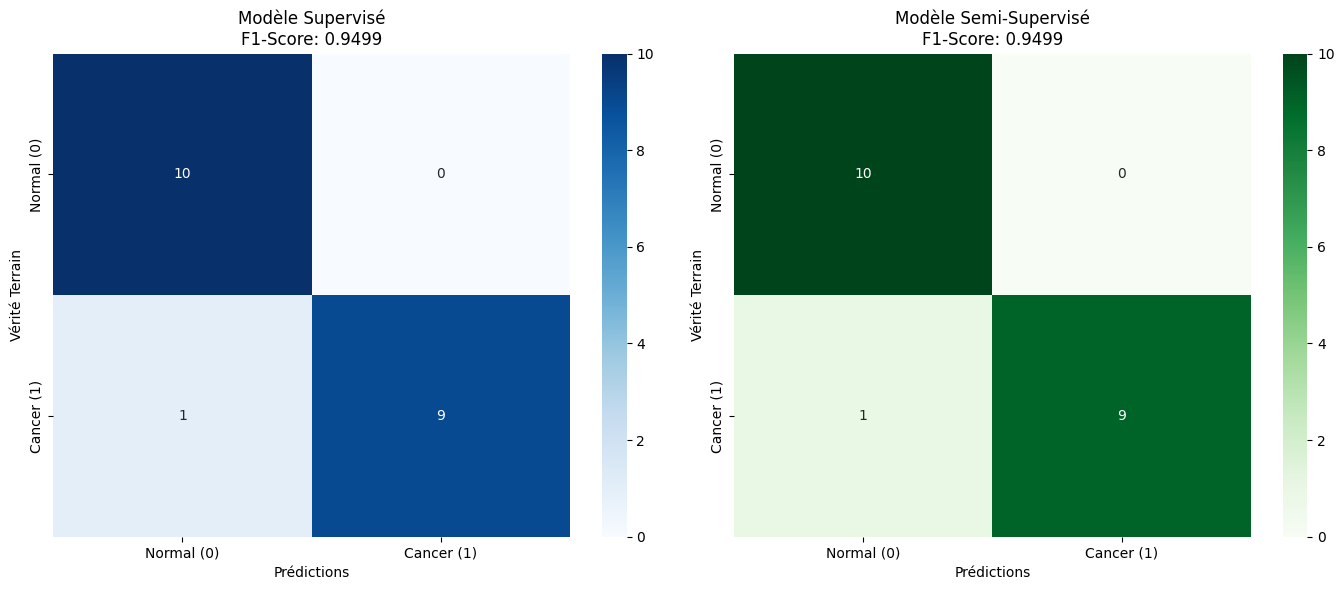


--- RAPPORT MODÈLE SUPERVISÉ ---
              precision    recall  f1-score   support

  Normal (0)       0.91      1.00      0.95        10
  Cancer (1)       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20


--- RAPPORT MODÈLE SEMI-SUPERVISÉ ---
              precision    recall  f1-score   support

  Normal (0)       0.91      1.00      0.95        10
  Cancer (1)       1.00      0.90      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20



In [18]:
def get_predictions(model, loader, device):
    """Extrait les étiquettes réelles et les prédictions d'un modèle pour un DataLoader."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())
    return y_true, y_pred

# Extraction des prédictions sur le jeu de test (jamais vu lors de l'entraînement)
y_true, y_pred_sup = get_predictions(model_supervised, test_loader, device)
_, y_pred_semi = get_predictions(model_semi_sup, test_loader, device)

# Configuration de l'affichage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['Normal (0)', 'Cancer (1)']

# Matrice 1 : Modèle Supervisé
cm_sup = confusion_matrix(y_true, y_pred_sup)
sns.heatmap(cm_sup, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f"Modèle Supervisé\nF1-Score: {f1_score(y_true, y_pred_sup, average='weighted'):.4f}")
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédictions')

# Matrice 2 : Modèle Semi-Supervisé
cm_semi = confusion_matrix(y_true, y_pred_semi)
sns.heatmap(cm_semi, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f"Modèle Semi-Supervisé\nF1-Score: {f1_score(y_true, y_pred_semi, average='weighted'):.4f}")
axes[1].set_ylabel('Vérité Terrain')
axes[1].set_xlabel('Prédictions')

plt.tight_layout()
plt.show()

# Affichage des rapports de classification complets
print("\n--- RAPPORT MODÈLE SUPERVISÉ ---")
print(classification_report(y_true, y_pred_sup, target_names=class_names))

print("\n--- RAPPORT MODÈLE SEMI-SUPERVISÉ ---")
print(classification_report(y_true, y_pred_semi, target_names=class_names))

In [19]:
# Calcul du gain de performance final
f1_final_sup = f1_score(y_true, y_pred_sup, average='weighted')
f1_final_semi = f1_score(y_true, y_pred_semi, average='weighted')

gain_f1 = ((f1_final_semi - f1_final_sup) / f1_final_sup) * 100

print("="*60)
print(" BILAN DE L'EXPÉRIMENTATION CURELYTICS-IA ")
print("="*60)
print(f"Performance approche classique (80 img) : {f1_final_sup:.4f}")
print(f"Performance approche hybride (5080 img) : {f1_final_semi:.4f}")
print("-"*60)
print(f"ÉVOLUTION GLOBALE DU MODÈLE : {gain_f1:+.2f} %")
print("="*60)


 BILAN DE L'EXPÉRIMENTATION CURELYTICS-IA 
Performance approche classique (80 img) : 0.9499
Performance approche hybride (5080 img) : 0.9499
------------------------------------------------------------
ÉVOLUTION GLOBALE DU MODÈLE : +0.00 %
